# Assignment 1 - Supermarket Sales Analysis

> Done by Pranav Jahagirdar

## Dataset

https://drive.google.com/file/d/1IODZF8at54psKhh3bEMyU6sIk74_7nNm/view?usp=drive_link

This dataset contains daily sales data from a supermarket, including product categories, branch,
customer type, gender, and total sales.

## Tasks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### 1. Data Loading and Inspection

In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")

df.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


In [3]:
print("Shape of dataset:", df.shape)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Shape of dataset: (1000, 17)

Data Types:

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Missing Values:

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time       

### 2. Data Cleaning and Preparation

In [4]:
df = df.drop_duplicates()

df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df["Date"].dtype

dtype('<M8[ns]')

In [6]:
if "Total" in df.columns:
    df["TotalSales"] = df["Total"]
else:
    df["TotalSales"] = df["Unit price"] * df["Quantity"]

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,TotalSales
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,522.83
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,76.40
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,324.31
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,465.76
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,604.17


### 3. Exploratory Data Analysis

In [7]:
top_products = df.groupby("Product line")["TotalSales"].sum().sort_values(ascending=False)

top_products.head(3)

,TotalSales
Product line,
Food and beverages,53471.28
Sports and travel,52497.93
Electronic accessories,51750.03


In [8]:
branch_avg = df.groupby("Branch")["TotalSales"].mean().sort_values(ascending=False)

branch_avg

,TotalSales
Branch,
Giza,321.047348
Cairo,304.640482
Alex,297.480029


In [9]:
customer_distribution = df["Customer type"].value_counts()

customer_distribution

,count
Customer type,
Member,565
Normal,435


In [10]:
avg_spending = df.groupby("Customer type")["TotalSales"].mean()

avg_spending

,TotalSales
Customer type,
Member,319.755186
Normal,291.783218


### 4. Visualizations

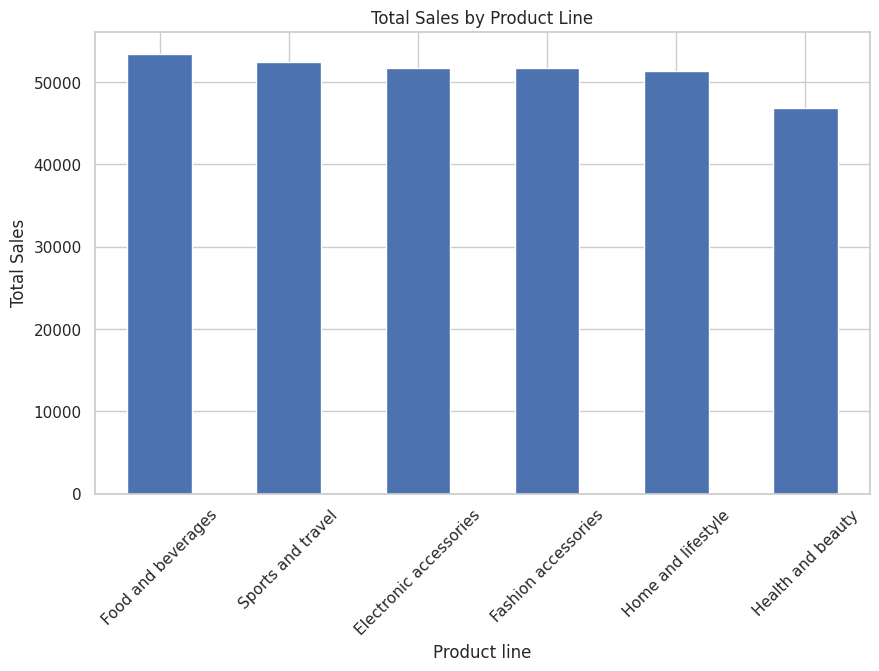

In [11]:
plt.figure(figsize=(10,6))
top_products.plot(kind="bar")
plt.title("Total Sales by Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

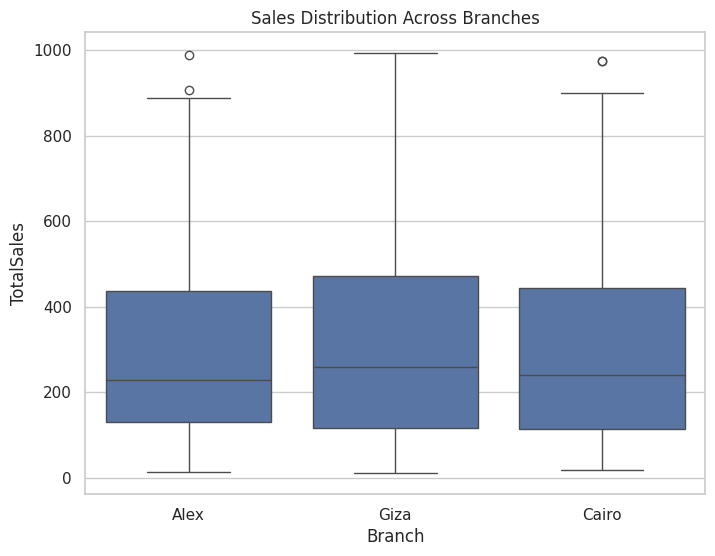

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Branch", y="TotalSales", data=df)
plt.title("Sales Distribution Across Branches")
plt.show()

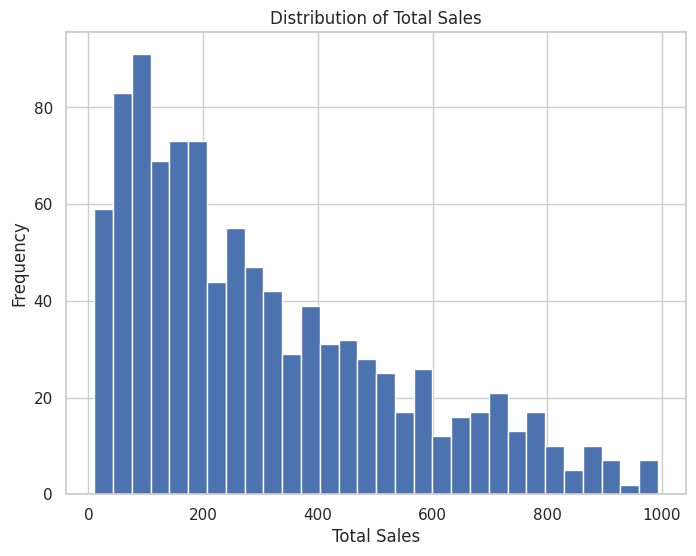

In [13]:
plt.figure(figsize=(8,6))
plt.hist(df["TotalSales"], bins=30)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

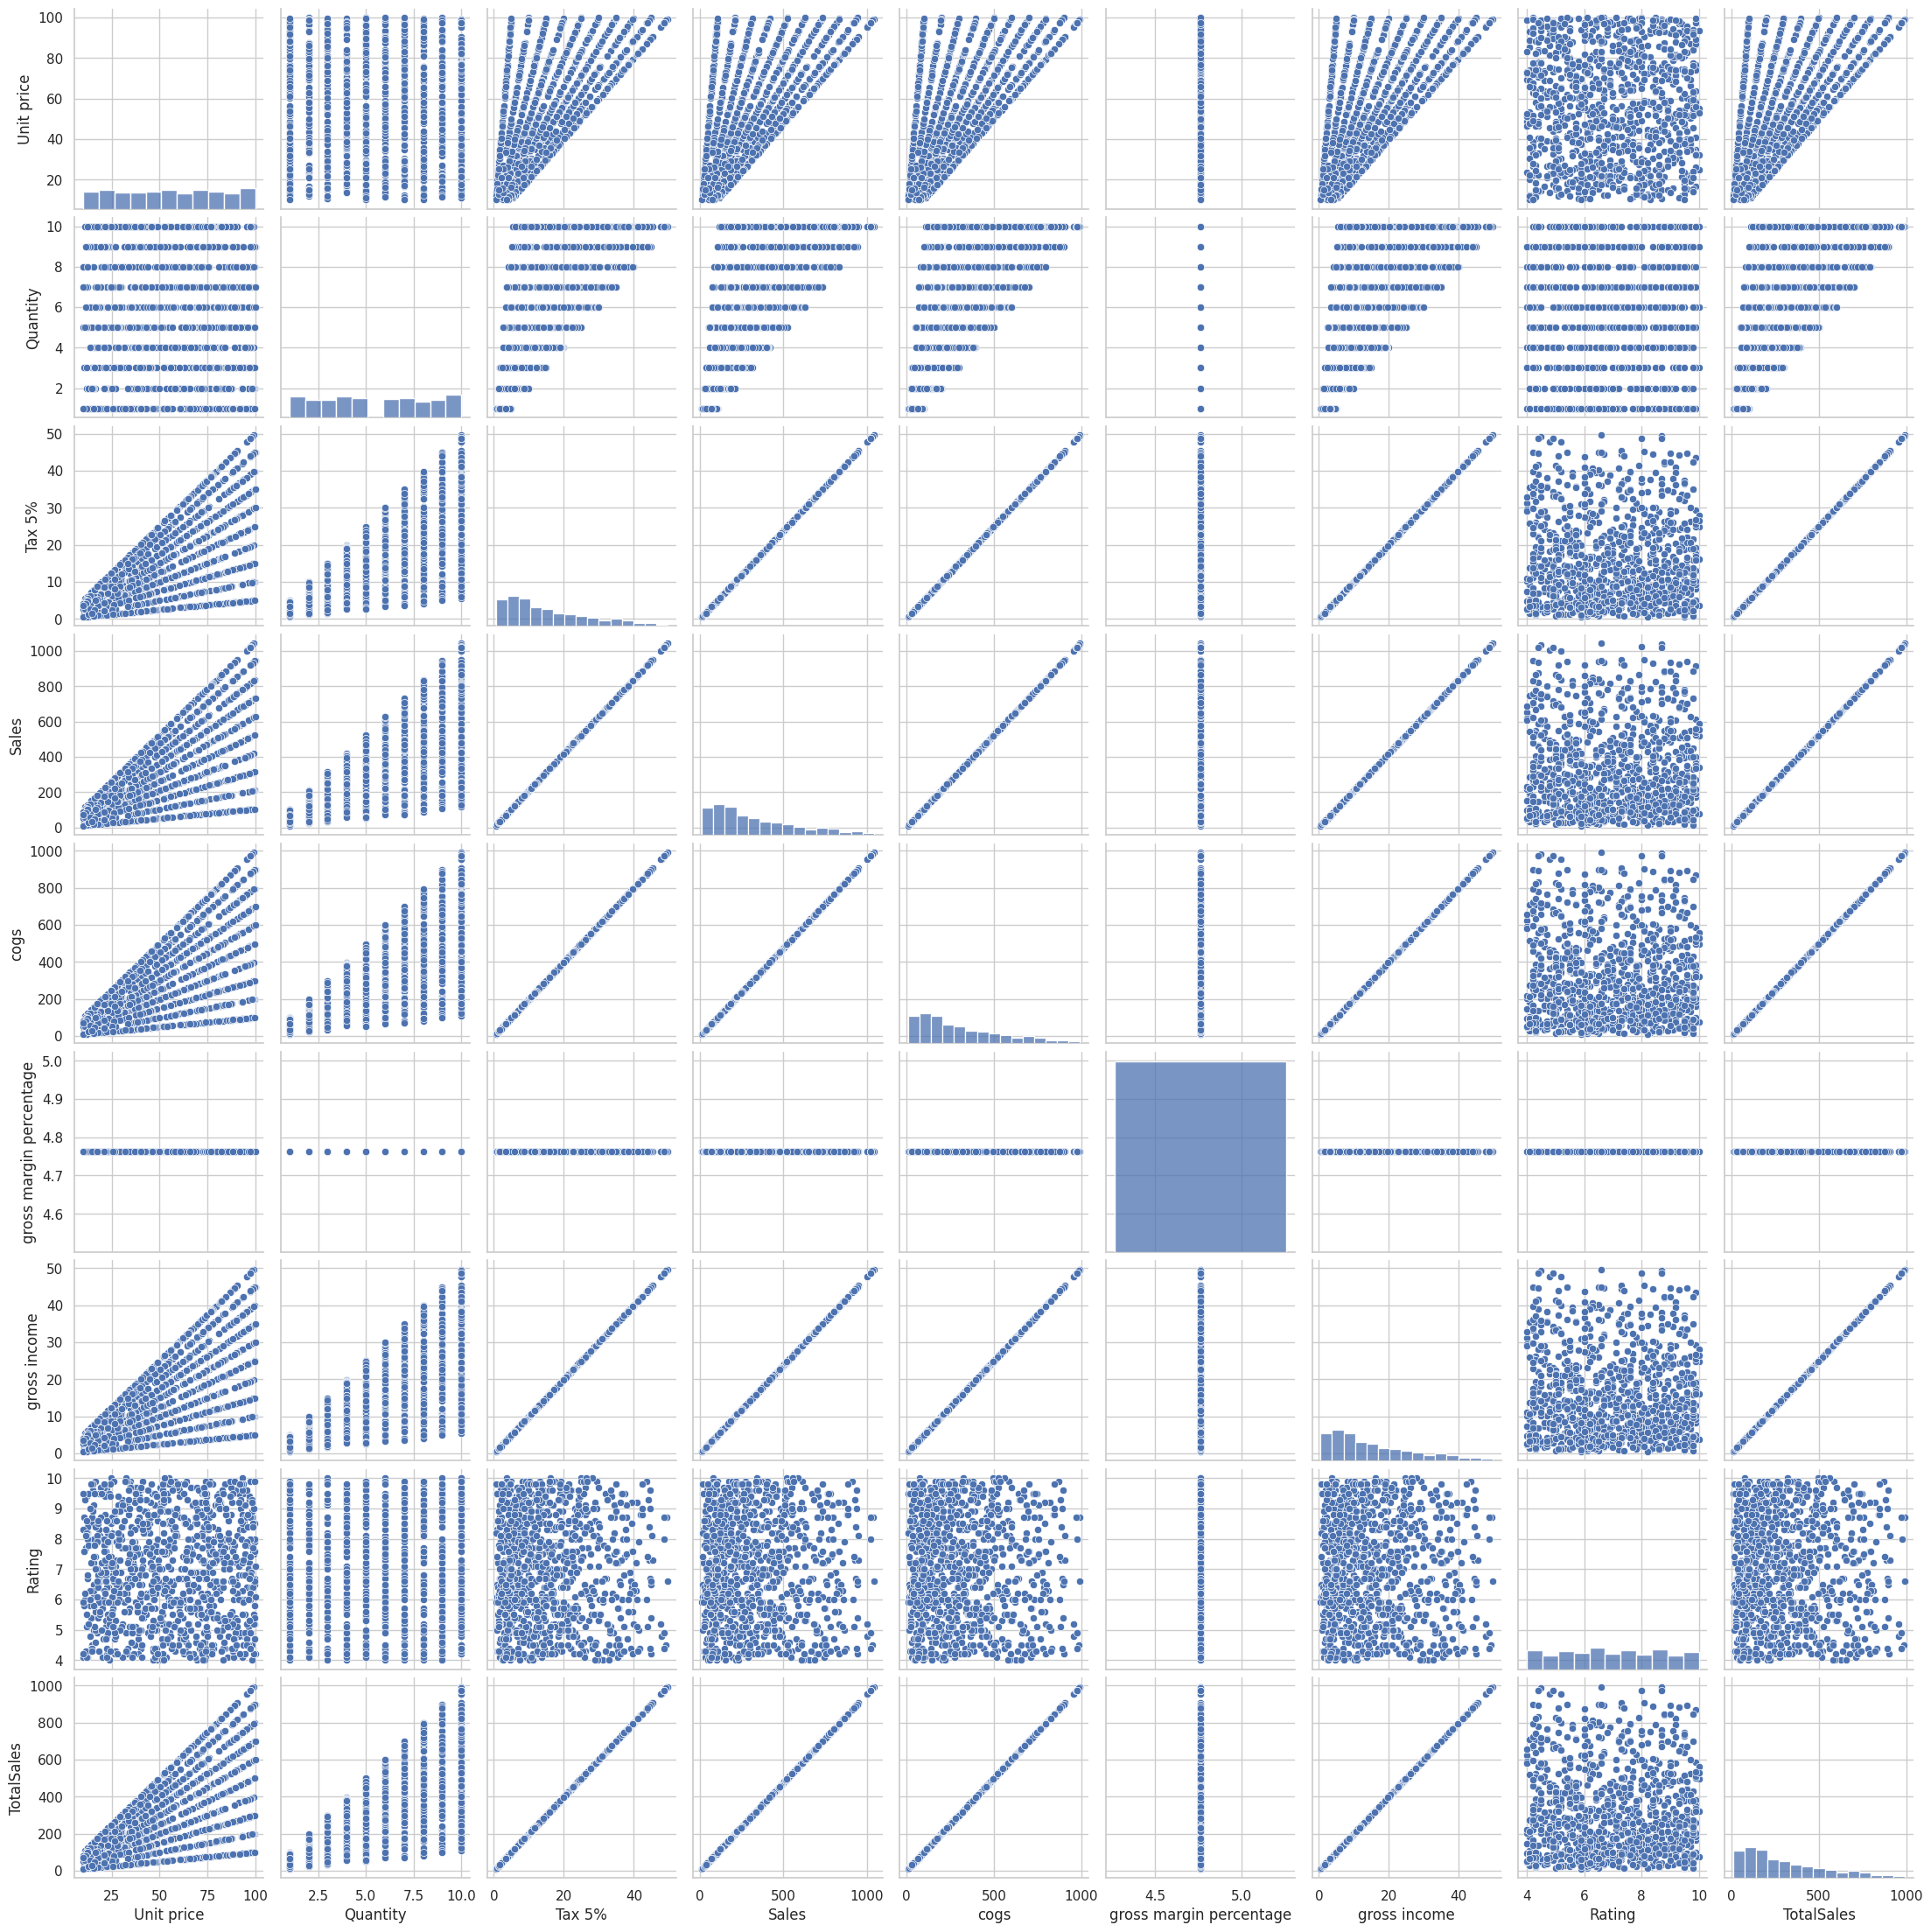

In [14]:
numerical_df = df.select_dtypes(include=np.number)

sns.pairplot(numerical_df)
plt.show()

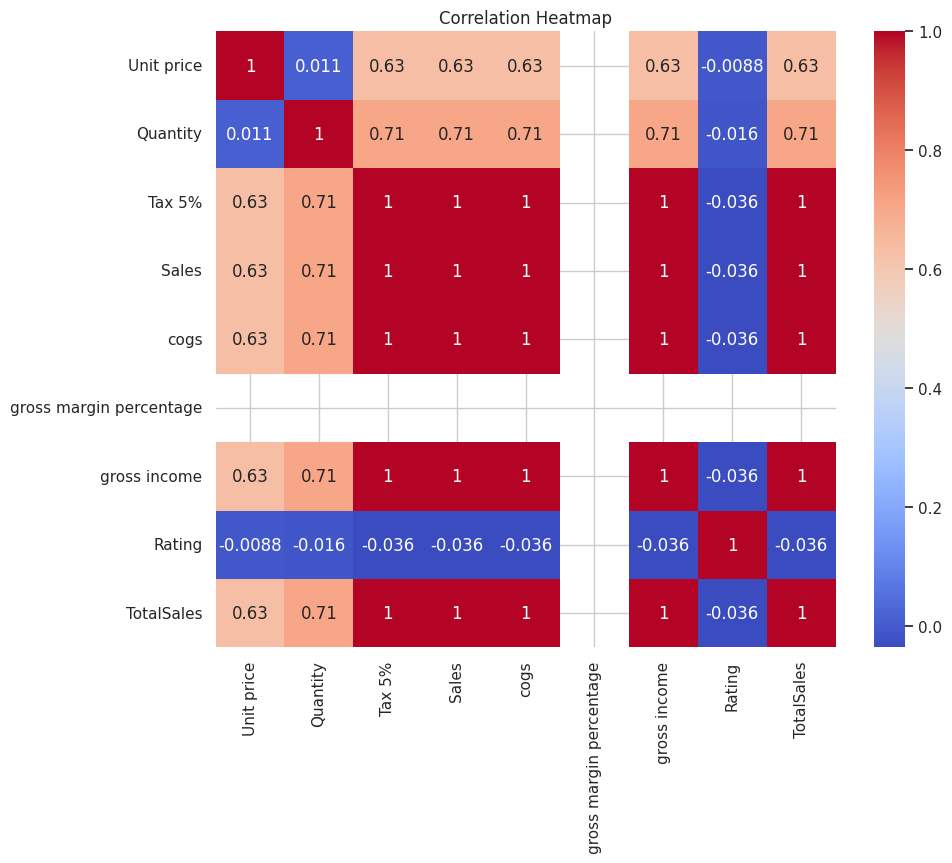

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 5. Analytical Insight Questions

1. Product Line with Consistent Sales:
By observing the boxplot and grouped statistics, the product line with the least variation across branches is the most consistent performer.

2. Influence of Gender on Average Sales:
By comparing average sales grouped by Gender, we can observe whether there is a significant difference.
If the mean difference is small, gender does not significantly influence sales.

3. Business Insight:
If Members spend more on average than Normal customers, the supermarket should:
- Promote membership programs
- Offer loyalty discounts
- Provide exclusive deals

This could increase overall revenue and customer retention.